# TheLook Growth & Retention Audit — Pandas Analysis

### Почему fashion-маркетплейс теряет деньги и повторных покупателей

**Уровень кода:** `Junior / Junior+`  
**Основной инструмент:** `Python / Pandas`  
**Дополнительно:** `NumPy` · `SciPy` · `statsmodels` · `Matplotlib` · `Seaborn`  
**SQL вынесен отдельно:** `../sql/` — запросы для BigQuery  
**Источник:** публичный синтетический датасет `bigquery-public-data.thelook_ecommerce`

Код построен на стандартных операциях `read_csv`, `merge`, `groupby`, `agg`, `pivot_table`, `qcut` и визуализации. Сложные производственные абстракции намеренно не используются: каждую ячейку можно объяснить на собеседовании junior / junior+.

---

## tl;dr

Все расчёты ниже выполнены через `Pandas`; SQL-код не встроен в notebook.

- Проанализированы **7 таблиц**, **124 923 заказа** и **2,4 млн событий**.
- Net Revenue Proxy = **$8,07 млн**, Gross Profit Proxy = **$4,19 млн**, margin = **51,9%**.
- Return Rate = **11,8%**, Cancellation Rate = **15,0%**.
- Repeat Purchase Rate = **30,4%**; M1 retention около **5%**.
- RFM показывает, какие группы клиентов дают основную выручку.
- Учебная A/B-симуляция проверяет конверсию обычным z-test и отдельно контролирует экономику.

Проект отвечает на вопросы:

1. Как меняются Net Revenue и Gross Profit после исключения отмен и возвратов?
2. Где пользователи теряются в session funnel?
3. Как выглядит repeat-purchase retention и кто входит в ключевые RFM-сегменты?
4. Какие категории, склады и сроки доставки создают операционный риск?
5. Стоит ли масштабировать бесплатную доставку для новых пользователей?


## 1. Context & Methods

### Разделение технологий

- **Pandas notebook** — загрузка CSV, очистка, объединение таблиц, расчёт метрик, сегментация и графики.
- **BigQuery** — отдельный SQL-слой с теми же бизнес-определениями метрик.

Такое разделение показывает две самостоятельные компетенции и не прячет SQL внутри Python-строк.

### Key Assumptions

- `GMV` — сумма `sale_price` всех заказов, кроме `Cancelled`.
- `Net Revenue Proxy` — продажи без `Cancelled` и `Returned`.
- `Gross Profit Proxy = Net Revenue − product cost`; в данных нет маркетинга, налогов и стоимости доставки.
- Повторный покупатель имеет минимум 2 заказа без отмен и возвратов.
- Последний неполный месяц исключён из сравнений динамики.
- Наблюдательные связи не трактуются как причинность.
- A/B-тест является учебной симуляцией на распределении чеков и маржи TheLook.


### Модель данных и аналитическая гранулярность

```text
users (1) ─────< orders (1) ─────< order_items >──── (1) products
   │                                      │                    │
   └──────< events                        └── inventory_items   └── distribution_centers
```

Перед объединениями `order_items` агрегируются до `order_id`. Итоговая витрина `order_mart` имеет строгую гранулярность:

> **одна строка = один заказ**

In [1]:
# 1.1 Импорты, настройки и пути
from pathlib import Path
from urllib.request import urlretrieve
from zipfile import ZipFile
import json
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", "{:,.3f}".format)
sns.set_theme(style="whitegrid")

COLORS = {
    "primary": "#2457C5",
    "accent": "#E86A33",
    "good": "#178A63",
    "bad": "#C83E4D",
    "muted": "#728197",
}

# Ищем корень проекта независимо от того, откуда запущено ядро Jupyter.
start_dir = Path.cwd().resolve()
project_candidates = []

# При необходимости путь можно задать до запуска notebook:
# export THELOOK_PROJECT_ROOT="/path/to/thelook-growth-analytics"
configured_root = os.environ.get("THELOOK_PROJECT_ROOT")
if configured_root:
    project_candidates.append(Path(configured_root).expanduser().resolve())

for folder in [start_dir, *start_dir.parents]:
    project_candidates.append(folder)
    project_candidates.append(folder / "thelook-growth-analytics")

# Частые места клонирования проекта на локальном компьютере.
project_candidates.extend([
    Path.home() / "thelook-growth-analytics",
    Path.home() / "Documents" / "thelook-growth-analytics",
    Path.home() / "Documents" / "New project" / "thelook-growth-analytics",
])

PROJECT_ROOT = None
for candidate in project_candidates:
    notebook_marker = candidate / "notebooks" / "01_thelook_pandas_analysis.ipynb"
    if notebook_marker.exists() and (candidate / "README.md").exists():
        PROJECT_ROOT = candidate.resolve()
        break

RUNNING_IN_REPOSITORY = PROJECT_ROOT is not None

if not RUNNING_IN_REPOSITORY:
    # Автономный режим: создаём data/ и outputs/ рядом с текущей папкой.
    PROJECT_ROOT = start_dir
    print("Репозиторий не найден — используется автономный режим")
else:
    print("Корень проекта определён автоматически")

RAW_DIR = PROJECT_ROOT / "data" / "raw"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "pandas"
TABLES_DIR = OUTPUT_DIR / "tables"
FIGURES_DIR = OUTPUT_DIR / "figures"

for folder in [RAW_DIR, TABLES_DIR, FIGURES_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Версия Pandas:", pd.__version__)


Корень проекта определён автоматически
Версия Pandas: 2.3.3


In [2]:
# 1.2 Проверяем наличие исходных CSV
DATASET_URL = (
    "https://www.kaggle.com/api/v1/datasets/download/"
    "daichiuchigashima/thelook-ecommerce?datasetVersionNumber=1&raw=false"
)

TABLE_NAMES = [
    "users", "orders", "order_items", "products",
    "events", "inventory_items", "distribution_centers",
]

csv_files = {
    name: RAW_DIR / f"thelook_ecommerce.{name}.csv"
    for name in TABLE_NAMES
}

missing_tables = [name for name, path in csv_files.items() if not path.exists()]
archive_path = PROJECT_ROOT / "data" / "thelook-ecommerce.zip"

if missing_tables and not archive_path.exists():
    print("Скачиваем публичный snapshot...")
    urlretrieve(DATASET_URL, archive_path)

if missing_tables:
    print("Распаковываем CSV...")
    with ZipFile(archive_path) as archive:
        archive.extractall(RAW_DIR)

assert all(path.exists() for path in csv_files.values()), "Не все CSV-файлы найдены"
print("Все 7 таблиц готовы к загрузке")


Все 7 таблиц готовы к загрузке


## 2. Data

### 2.1 Загрузка и оптимизация типов

Для большой таблицы `events` загружаются только необходимые поля. Повторяющиеся строковые признаки переводятся в `category`, что снижает потребление памяти.

In [3]:
# 2.1 Загружаем таблицы через Pandas
users = pd.read_csv(
    csv_files["users"],
    usecols=["id", "country", "traffic_source", "age", "gender", "created_at"],
)

orders = pd.read_csv(csv_files["orders"])

order_items = pd.read_csv(
    csv_files["order_items"],
    usecols=["id", "order_id", "user_id", "product_id", "inventory_item_id", "status", "created_at", "sale_price"],
)

products = pd.read_csv(csv_files["products"])

events = pd.read_csv(
    csv_files["events"],
    usecols=["session_id", "traffic_source", "browser", "event_type"],
    dtype={
        "session_id": "string",
        "traffic_source": "category",
        "browser": "category",
        "event_type": "category",
    },
)

inventory_items = pd.read_csv(
    csv_files["inventory_items"],
    usecols=["id", "product_id", "created_at", "sold_at", "cost", "product_distribution_center_id"],
)

distribution_centers = pd.read_csv(csv_files["distribution_centers"])

# Приводим даты к одному формату.
for column in ["created_at"]:
    users[column] = pd.to_datetime(users[column], format="mixed", errors="coerce", utc=True).dt.tz_localize(None)

for column in ["created_at", "shipped_at", "delivered_at", "returned_at"]:
    orders[column] = pd.to_datetime(orders[column], format="mixed", errors="coerce", utc=True).dt.tz_localize(None)

for column in ["created_at", "sold_at"]:
    inventory_items[column] = pd.to_datetime(inventory_items[column], format="mixed", errors="coerce", utc=True).dt.tz_localize(None)

frames = {
    "users": users,
    "orders": orders,
    "order_items": order_items,
    "products": products,
    "events": events,
    "inventory_items": inventory_items,
    "distribution_centers": distribution_centers,
}

source_rows = []
for name, table in frames.items():
    source_rows.append({
        "table": name,
        "rows": len(table),
        "columns": table.shape[1],
        "memory_mb": table.memory_usage(deep=True).sum() / 1024 ** 2,
    })

source_inventory = pd.DataFrame(source_rows).sort_values("rows", ascending=False)
display(source_inventory.style.format({"rows": "{:,.0f}", "memory_mb": "{:.1f}"}))


,table,rows,columns,memory_mb
4,events,"2,420,738",4,203.2
5,inventory_items,"487,901",6,22.3
2,order_items,"180,952",8,30.6
1,orders,"124,923",9,19.9
0,users,"100,000",6,17.8
3,products,"29,120",9,10.6
6,distribution_centers,10,4,0.0


### 2.2 Data Quality

Проверяются первичные ключи, пропуски, ссылочная целостность и невозможная хронология. Результаты сохраняются как отдельные проверочные таблицы.

In [4]:
# 2.2 Primary-key profile
primary_keys = {
    "users": "id",
    "orders": "order_id",
    "order_items": "id",
    "products": "id",
    "inventory_items": "id",
    "distribution_centers": "id",
}

quality_rows = []
for table_name, key in primary_keys.items():
    frame = frames[table_name]
    quality_rows.append({
        "table_name": table_name,
        "row_count": len(frame),
        "unique_keys": frame[key].nunique(dropna=True),
        "null_keys": frame[key].isna().sum(),
        "duplicate_keys": frame[key].duplicated().sum(),
    })

table_quality = pd.DataFrame(quality_rows).sort_values("row_count", ascending=False)
table_quality.to_csv(TABLES_DIR / "01_table_quality.csv", index=False)
display(table_quality.style.format(thousands=","))

,table_name,row_count,unique_keys,null_keys,duplicate_keys
4,inventory_items,"487,901","487,901",0,0
2,order_items,"180,952","180,952",0,0
1,orders,"124,923","124,923",0,0
0,users,"100,000","100,000",0,0
3,products,"29,120","29,120",0,0
5,distribution_centers,10,10,0,0


In [5]:
# 2.3 Referential integrity and chronology
integrity_checks = pd.DataFrame([
    {"check_name": "orders_without_user", "issue_count": (~orders["user_id"].isin(users["id"])).sum()},
    {"check_name": "items_without_order", "issue_count": (~order_items["order_id"].isin(orders["order_id"])).sum()},
    {"check_name": "items_without_product", "issue_count": (~order_items["product_id"].isin(products["id"])).sum()},
    {"check_name": "shipped_before_created", "issue_count": ((orders["shipped_at"].notna()) & (orders["shipped_at"] < orders["created_at"])).sum()},
    {"check_name": "delivered_before_shipped", "issue_count": ((orders["delivered_at"].notna()) & (orders["shipped_at"].notna()) & (orders["delivered_at"] < orders["shipped_at"])).sum()},
    {"check_name": "returned_before_delivered", "issue_count": ((orders["returned_at"].notna()) & (orders["delivered_at"].notna()) & (orders["returned_at"] < orders["delivered_at"])).sum()},
])
integrity_checks.to_csv(TABLES_DIR / "02_integrity_checks.csv", index=False)
display(integrity_checks)

quality_issue_count = int(table_quality[["null_keys", "duplicate_keys"]].sum().sum() + integrity_checks["issue_count"].sum())
display(Markdown(f"**Data Quality Gate:** найдено **{quality_issue_count:,}** нарушений ключей и проверяемой логики."))

,check_name,issue_count
0,orders_without_user,0
1,items_without_order,0
2,items_without_product,0
3,shipped_before_created,0
4,delivered_before_shipped,0
5,returned_before_delivered,0


**Data Quality Gate:** найдено **0** нарушений ключей и проверяемой логики.

### 2.3 Построение `order_mart` через `merge` и `groupby`

`products` присоединяется к `order_items` с проверкой `many_to_one`. Затем позиции агрегируются до заказа, и только после этого присоединяются `orders` и `users`.

In [6]:
# 2.4 Enrich order items and aggregate to order grain
products_dim = products.rename(columns={"id": "product_id"})[
    ["product_id", "cost", "category", "brand", "department", "distribution_center_id"]
]

item_enriched = order_items.merge(
    products_dim,
    on="product_id",
    how="left",
    validate="many_to_one",
)
item_enriched["item_profit"] = item_enriched["sale_price"] - item_enriched["cost"]
item_enriched["returned_item"] = item_enriched["status"].eq("Returned").astype("int8")

item_agg = (
    item_enriched.groupby("order_id", as_index=False, observed=True)
    .agg(
        item_count=("id", "size"),
        order_value=("sale_price", "sum"),
        product_cost=("cost", "sum"),
        gross_profit_before_status=("item_profit", "sum"),
        returned_item_count=("returned_item", "sum"),
    )
)

display(item_agg.head())

,order_id,item_count,order_value,product_cost,gross_profit_before_status,returned_item_count
0,1,2,63.990,26.724,37.266,2
1,2,1,58.990,26.840,32.150,0
2,3,3,93.490,47.776,45.714,0
3,4,3,85.640,41.677,43.963,0
4,5,1,279.000,122.202,156.798,0


In [7]:
# 2.5 Merge order and customer attributes
orders_base = orders.rename(columns={"created_at": "order_created_at"})
users_dim = users.rename(columns={
    "id": "user_id",
    "created_at": "user_created_at",
    "gender": "user_gender",
})

order_mart = (
    orders_base.merge(item_agg, on="order_id", how="left", validate="one_to_one")
    .merge(users_dim, on="user_id", how="left", validate="many_to_one")
)

numeric_item_columns = ["item_count", "order_value", "product_cost", "gross_profit_before_status", "returned_item_count"]
order_mart[numeric_item_columns] = order_mart[numeric_item_columns].fillna(0)
order_mart["is_net_order"] = ~order_mart["status"].isin(["Cancelled", "Returned"])
order_mart["net_revenue"] = order_mart["order_value"].where(order_mart["is_net_order"], 0.0)
order_mart["gross_profit"] = order_mart["gross_profit_before_status"].where(order_mart["is_net_order"], 0.0)
order_mart["days_to_ship"] = (order_mart["shipped_at"] - order_mart["order_created_at"]).dt.days
order_mart["days_in_transit"] = (order_mart["delivered_at"] - order_mart["shipped_at"]).dt.days
order_mart["days_to_deliver"] = (order_mart["delivered_at"] - order_mart["order_created_at"]).dt.days

grain_check = pd.DataFrame([{
    "rows_in_mart": len(order_mart),
    "unique_orders": order_mart["order_id"].nunique(),
    "one_row_per_order": len(order_mart) == order_mart["order_id"].nunique(),
    "missing_users": order_mart["country"].isna().sum(),
}])
assert bool(grain_check.loc[0, "one_row_per_order"]), "Нарушена гранулярность order_mart"
display(grain_check.style.format(thousands=","))

,rows_in_mart,unique_orders,one_row_per_order,missing_users
0,"124,923","124,923",True,0


## 3. Results

### 3.1 Executive KPI

Все KPI рассчитываются из одной Pandas-витрины. Это защищает проект от расхождения фильтров между разделами.

In [8]:
# 3.1 Executive KPI with Pandas
buyer_order_counts = (
    order_mart.loc[order_mart["is_net_order"]]
    .groupby("user_id", observed=True)["order_id"]
    .nunique()
)

non_cancelled = order_mart["status"].ne("Cancelled")
returned = order_mart["status"].eq("Returned")
cancelled = order_mart["status"].eq("Cancelled")
positive_net_orders = order_mart["net_revenue"].gt(0)

kpi = pd.DataFrame([{
    "orders": len(order_mart),
    "ordering_users": order_mart["user_id"].nunique(),
    "gmv": order_mart.loc[non_cancelled, "order_value"].sum(),
    "net_revenue": order_mart["net_revenue"].sum(),
    "gross_profit": order_mart["gross_profit"].sum(),
    "gross_margin": order_mart["gross_profit"].sum() / order_mart["net_revenue"].sum(),
    "return_rate": returned.sum() / non_cancelled.sum(),
    "cancellation_rate": cancelled.mean(),
    "aov": order_mart.loc[positive_net_orders, "net_revenue"].mean(),
    "avg_basket_size": order_mart.loc[order_mart["is_net_order"], "item_count"].mean(),
    "repeat_purchase_rate": buyer_order_counts.ge(2).mean(),
}])
kpi.to_csv(TABLES_DIR / "03_executive_kpi.csv", index=False)

kpi_cards = pd.DataFrame({
    "Метрика": ["Net Revenue", "Gross Profit", "Margin", "Orders", "AOV", "Return Rate", "Cancellation Rate", "Repeat Purchase Rate"],
    "Значение": [
        f"${kpi.net_revenue.iloc[0]:,.0f}", f"${kpi.gross_profit.iloc[0]:,.0f}",
        f"{kpi.gross_margin.iloc[0]:.1%}", f"{int(kpi.orders.iloc[0]):,}",
        f"${kpi.aov.iloc[0]:,.2f}", f"{kpi.return_rate.iloc[0]:.1%}",
        f"{kpi.cancellation_rate.iloc[0]:.1%}", f"{kpi.repeat_purchase_rate.iloc[0]:.1%}",
    ],
})
display(kpi_cards.style.hide(axis="index"))

Метрика,Значение
Net Revenue,"$8,067,639"
Gross Profit,"$4,185,726"
Margin,51.9%
Orders,"124,923"
AOV,$86.17
Return Rate,11.8%
Cancellation Rate,15.0%
Repeat Purchase Rate,30.4%


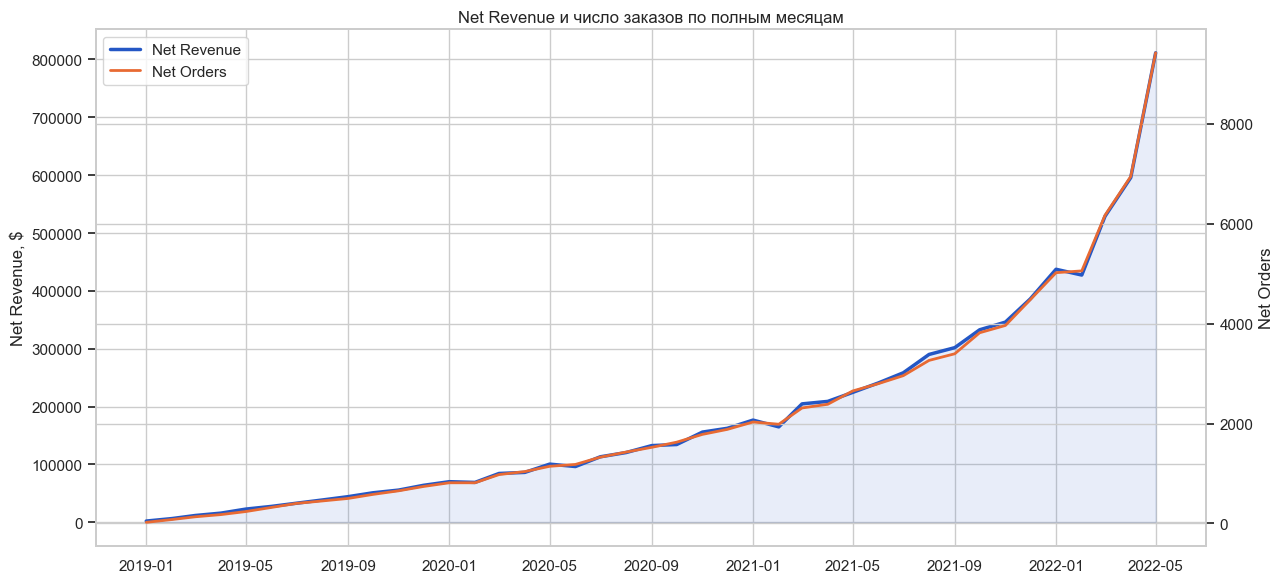

In [9]:
# 3.2 Monthly dynamics
monthly_base = order_mart.assign(
    month=order_mart["order_created_at"].dt.to_period("M").dt.to_timestamp(),
    net_buyer_id=order_mart["user_id"].where(order_mart["is_net_order"]),
    return_flag=returned.astype("int8"),
    non_cancelled_flag=non_cancelled.astype("int8"),
)
last_month = monthly_base["month"].max()
monthly_complete = monthly_base.loc[monthly_base["month"] < last_month]

monthly = (
    monthly_complete.groupby("month", as_index=False)
    .agg(
        net_orders=("is_net_order", "sum"),
        buyers=("net_buyer_id", "nunique"),
        net_revenue=("net_revenue", "sum"),
        gross_profit=("gross_profit", "sum"),
        returned_orders=("return_flag", "sum"),
        non_cancelled_orders=("non_cancelled_flag", "sum"),
    )
)
monthly["margin"] = monthly["gross_profit"] / monthly["net_revenue"]
monthly["return_rate"] = monthly["returned_orders"] / monthly["non_cancelled_orders"]
monthly.to_csv(TABLES_DIR / "04_monthly_metrics.csv", index=False)

fig, ax1 = plt.subplots(figsize=(13, 6))
ax1.plot(monthly["month"], monthly["net_revenue"], color=COLORS["primary"], linewidth=2.5, label="Net Revenue")
ax1.fill_between(monthly["month"], monthly["net_revenue"], color=COLORS["primary"], alpha=0.10)
ax1.set_title("Net Revenue и число заказов по полным месяцам")
ax1.set_ylabel("Net Revenue, $")
ax2 = ax1.twinx()
ax2.plot(monthly["month"], monthly["net_orders"], color=COLORS["accent"], linewidth=2, label="Net Orders")
ax2.set_ylabel("Net Orders")
lines = ax1.get_lines() + ax2.get_lines()
ax1.legend(lines, [line.get_label() for line in lines], loc="upper left")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "01_monthly_revenue_orders.png", bbox_inches="tight")
plt.show()

### 3.2 Session Funnel

`pd.crosstab` превращает события в бинарные признаки шагов на уровне `session_id`. Воронка строится только после перехода к одной строке на сессию.

,stage,sessions,conversion_from_all,conversion_from_previous
0,Все сессии,"680,952",100.0%,100.0%
1,Просмотр товара/категории,"680,952",100.0%,100.0%
2,Корзина,"430,715",63.3%,63.3%
3,Покупка,"180,952",26.6%,42.0%


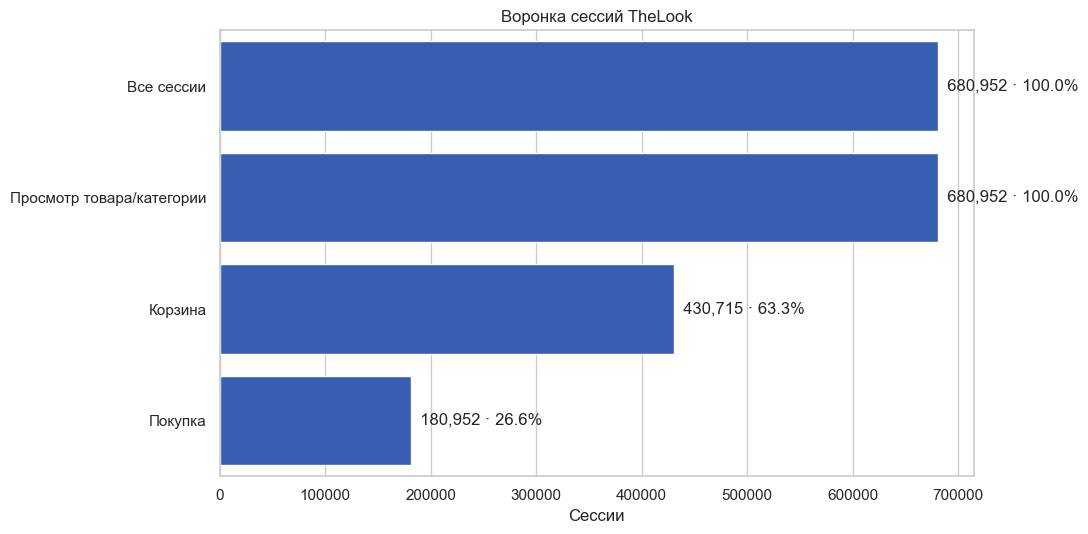

In [10]:
# 3.3 Session flags with pd.crosstab
event_flags = pd.crosstab(events["session_id"], events["event_type"]).gt(0).astype("int8")
for event_type in ["department", "product", "cart", "purchase"]:
    if event_type not in event_flags.columns:
        event_flags[event_type] = 0

session_flags = pd.DataFrame(index=event_flags.index)
session_flags["product_view"] = event_flags[["department", "product"]].max(axis=1)
session_flags["cart"] = event_flags["cart"]
session_flags["purchase"] = event_flags["purchase"]

session_dimensions = (
    events.drop_duplicates("session_id")
    .set_index("session_id")[["traffic_source", "browser"]]
)
session_data = session_dimensions.join(session_flags, how="inner")

funnel = pd.DataFrame({
    "stage": ["Все сессии", "Просмотр товара/категории", "Корзина", "Покупка"],
    "sessions": [len(session_data), session_data["product_view"].sum(), session_data["cart"].sum(), session_data["purchase"].sum()],
})
funnel["conversion_from_all"] = funnel["sessions"] / funnel.loc[0, "sessions"]
funnel["conversion_from_previous"] = funnel["sessions"] / funnel["sessions"].shift(1)
funnel.loc[0, "conversion_from_previous"] = 1.0
funnel.to_csv(TABLES_DIR / "05_funnel.csv", index=False)
display(funnel.style.format({"sessions": "{:,.0f}", "conversion_from_all": "{:.1%}", "conversion_from_previous": "{:.1%}"}))

fig, ax = plt.subplots(figsize=(11, 5.5))
sns.barplot(data=funnel, x="sessions", y="stage", color=COLORS["primary"], ax=ax)
for idx, row in funnel.iterrows():
    ax.text(row["sessions"], idx, f"  {row['sessions']:,.0f} · {row['conversion_from_all']:.1%}", va="center")
ax.set_title("Воронка сессий TheLook")
ax.set_xlabel("Сессии")
ax.set_ylabel("")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "02_session_funnel.png", bbox_inches="tight")
plt.show()

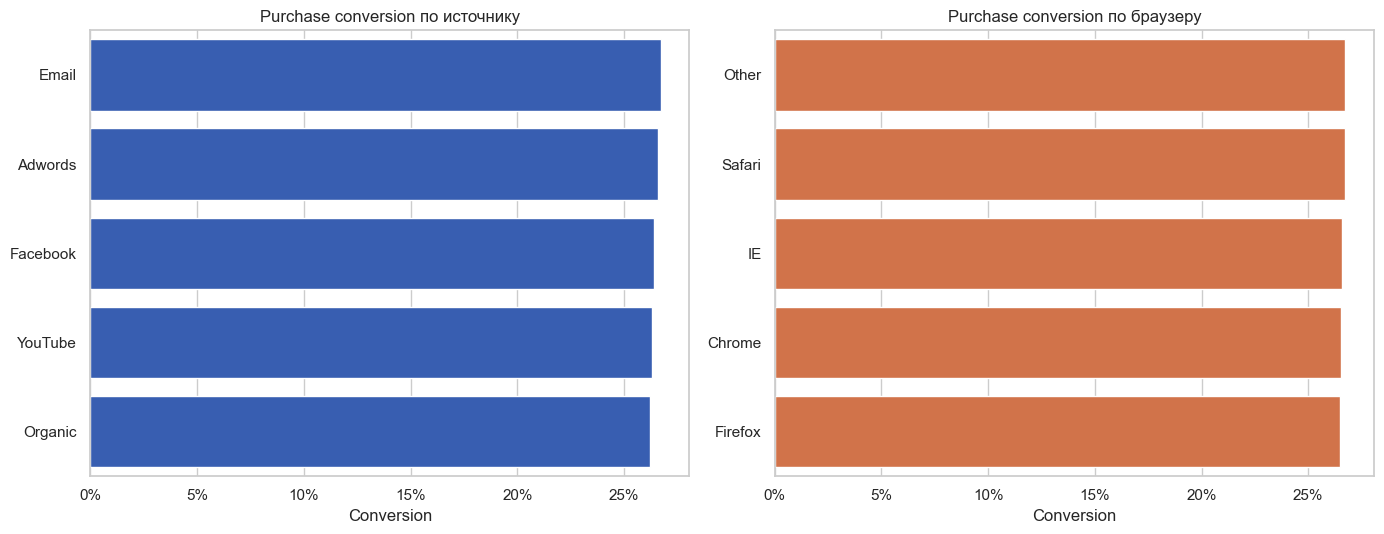

In [11]:
# 3.4 Conversion by source and browser
segment_frames = []
for dimension in ["traffic_source", "browser"]:
    segment = (
        session_data.groupby(dimension, observed=True)
        .agg(
            sessions=("purchase", "size"),
            view_rate=("product_view", "mean"),
            cart_rate=("cart", "mean"),
            purchase_rate=("purchase", "mean"),
        )
        .reset_index(names="segment")
    )
    segment.insert(0, "dimension", dimension)
    segment_frames.append(segment)

segment_funnel = pd.concat(segment_frames, ignore_index=True)
segment_funnel.to_csv(TABLES_DIR / "06_segment_funnel.csv", index=False)
traffic_funnel = segment_funnel.query("dimension == 'traffic_source'").sort_values("purchase_rate", ascending=False)
browser_funnel = segment_funnel.query("dimension == 'browser'").sort_values("purchase_rate", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
sns.barplot(data=traffic_funnel, x="purchase_rate", y="segment", color=COLORS["primary"], ax=axes[0])
axes[0].set_title("Purchase conversion по источнику")
axes[0].set_xlabel("Conversion")
axes[0].set_ylabel("")
axes[0].xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
sns.barplot(data=browser_funnel, x="purchase_rate", y="segment", color=COLORS["accent"], ax=axes[1])
axes[1].set_title("Purchase conversion по браузеру")
axes[1].set_xlabel("Conversion")
axes[1].set_ylabel("")
axes[1].xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "03_segment_conversion.png", bbox_inches="tight")
plt.show()

### 3.3 Repeat-Purchase Retention

Когорта — месяц первой успешной покупки. Алгоритм состоит из четырёх понятных шагов:

1. Находим месяц покупки каждого клиента.
2. Находим месяц его первой покупки — когорту.
3. Считаем возраст когорты в месяцах.
4. Строим `pivot_table` и делим активных клиентов на размер когорты.


In [12]:
# 3.5 Когортный retention через groupby и pivot_table
purchases = order_mart.loc[
    order_mart["is_net_order"],
    ["user_id", "order_created_at"],
].copy()

purchases["order_month"] = (
    purchases["order_created_at"].dt.to_period("M").dt.to_timestamp()
)
purchases = purchases[["user_id", "order_month"]].drop_duplicates()

# Месяц первой покупки каждого клиента.
first_purchase = (
    purchases.groupby("user_id", as_index=False)["order_month"]
    .min()
    .rename(columns={"order_month": "cohort_month"})
)
purchases = purchases.merge(first_purchase, on="user_id", how="left")

# Сколько месяцев прошло после первой покупки.
purchases["cohort_age"] = (
    (purchases["order_month"].dt.year - purchases["cohort_month"].dt.year) * 12
    + purchases["order_month"].dt.month
    - purchases["cohort_month"].dt.month
)

cohort_counts = purchases.pivot_table(
    index="cohort_month",
    columns="cohort_age",
    values="user_id",
    aggfunc="nunique",
    fill_value=0,
)

cohort_sizes = cohort_counts[0]
retention_matrix = cohort_counts.div(cohort_sizes, axis=0)

# Будущие месяцы для молодых когорт оставляем пустыми.
last_month = purchases["order_month"].max()
for cohort_month in retention_matrix.index:
    available_age = (
        (last_month.year - cohort_month.year) * 12
        + last_month.month
        - cohort_month.month
    )
    retention_matrix.loc[cohort_month, available_age + 1:] = np.nan

retention_long = (
    retention_matrix.reset_index()
    .melt(id_vars="cohort_month", var_name="cohort_age", value_name="retention")
)
retention_long["cohort_size"] = retention_long["cohort_month"].map(cohort_sizes)
retention_long["active_buyers"] = retention_long["retention"] * retention_long["cohort_size"]
retention_long.to_csv(TABLES_DIR / "07_cohort_retention_long.csv", index=False)


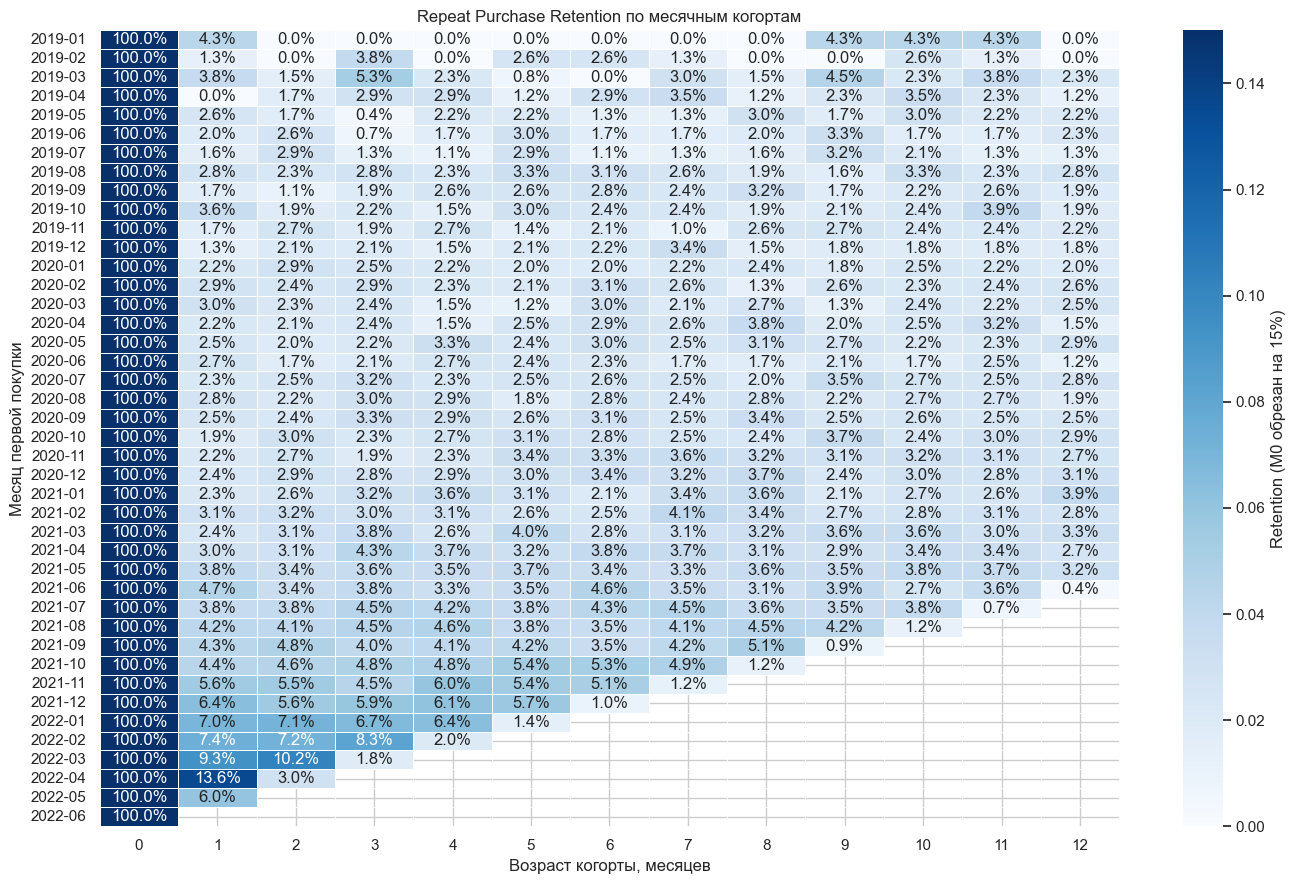

,M1,M3,M6
retention,5.1%,3.9%,3.2%


In [13]:
# 3.5.2 Визуализируем retention и считаем M1 / M3 / M6
plot_matrix = retention_matrix.iloc[:, :13].copy()
plot_matrix.index = plot_matrix.index.strftime("%Y-%m")

fig, ax = plt.subplots(figsize=(14, 9))
sns.heatmap(
    plot_matrix,
    cmap="Blues",
    vmin=0,
    vmax=0.15,
    annot=True,
    fmt=".1%",
    linewidths=0.4,
    cbar_kws={"label": "Retention (M0 обрезан на 15%)"},
    ax=ax,
)
ax.set_title("Repeat Purchase Retention по месячным когортам")
ax.set_xlabel("Возраст когорты, месяцев")
ax.set_ylabel("Месяц первой покупки")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "04_retention_heatmap.png", bbox_inches="tight")
plt.show()

# Взвешенный retention: активные клиенты / все клиенты созревших когорт.
retention_results = {}
for age in [1, 3, 6]:
    mature_cohorts = retention_matrix[age].dropna().index
    active_buyers = cohort_counts.loc[mature_cohorts, age].sum()
    all_buyers = cohort_sizes.loc[mature_cohorts].sum()
    retention_results[f"M{age}"] = active_buyers / all_buyers

weighted_retention = pd.Series(retention_results)
display(weighted_retention.to_frame("retention").T.style.format("{:.1%}"))


### 3.4 RFM Segmentation

RFM отвечает на три вопроса:

- **Recency** — как давно клиент покупал?
- **Frequency** — сколько заказов он сделал?
- **Monetary** — сколько выручки принёс?

`pd.qcut` делит клиентов на пять примерно равных групп. Score 5 означает лучший результат. В BigQuery аналогичная логика реализована через `NTILE(5)`.


In [14]:
# 3.6 RFM через groupby, qcut и np.select
net_orders = order_mart[order_mart["is_net_order"]].copy()
reference_date = net_orders["order_created_at"].max().normalize() + pd.Timedelta(days=1)

rfm_users = (
    net_orders.groupby("user_id", as_index=False)
    .agg(
        last_order_at=("order_created_at", "max"),
        frequency=("order_id", "nunique"),
        monetary=("net_revenue", "sum"),
    )
)

rfm_users["recency_days"] = (
    reference_date - rfm_users["last_order_at"].dt.normalize()
).dt.days

# rank(method="first") помогает qcut корректно работать с одинаковыми значениями.
rfm_users["r_score"] = pd.qcut(
    rfm_users["recency_days"].rank(method="first", ascending=False),
    5,
    labels=[1, 2, 3, 4, 5],
).astype(int)

rfm_users["f_score"] = pd.qcut(
    rfm_users["frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5],
).astype(int)

rfm_users["m_score"] = pd.qcut(
    rfm_users["monetary"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5],
).astype(int)

conditions = [
    (rfm_users["r_score"] >= 4) & (rfm_users["f_score"] >= 4) & (rfm_users["m_score"] >= 4),
    (rfm_users["r_score"] >= 3) & (rfm_users["f_score"] >= 4),
    (rfm_users["r_score"] == 5) & (rfm_users["f_score"] <= 2),
    (rfm_users["r_score"] <= 2) & (rfm_users["f_score"] >= 4) & (rfm_users["m_score"] >= 4),
    (rfm_users["r_score"] <= 2) & (rfm_users["f_score"] >= 3),
    (rfm_users["r_score"] <= 2) & (rfm_users["f_score"] <= 2),
]

segment_names = [
    "Champions", "Loyal Customers", "New Customers",
    "High Value At Risk", "At Risk", "Lost Customers",
]

rfm_users["segment"] = np.select(
    conditions,
    segment_names,
    default="Potential Loyalists",
)


,segment,customers,revenue,avg_order_count,avg_recency_days,customer_share,revenue_share
1,Champions,"8,152","$2,087,275",2.44,49,12.3%,25.9%
6,Potential Loyalists,"17,101","$1,467,239",1.00,122,25.9%,18.2%
4,Loyal Customers,"9,964","$1,264,789",1.90,126,15.1%,15.7%
2,High Value At Risk,"4,524","$1,089,418",2.13,468,6.8%,13.5%
3,Lost Customers,"12,141","$1,052,693",1.00,552,18.4%,13.0%
0,At Risk,"9,794","$726,966",1.17,535,14.8%,9.0%
5,New Customers,"4,470","$379,259",1.00,18,6.8%,4.7%


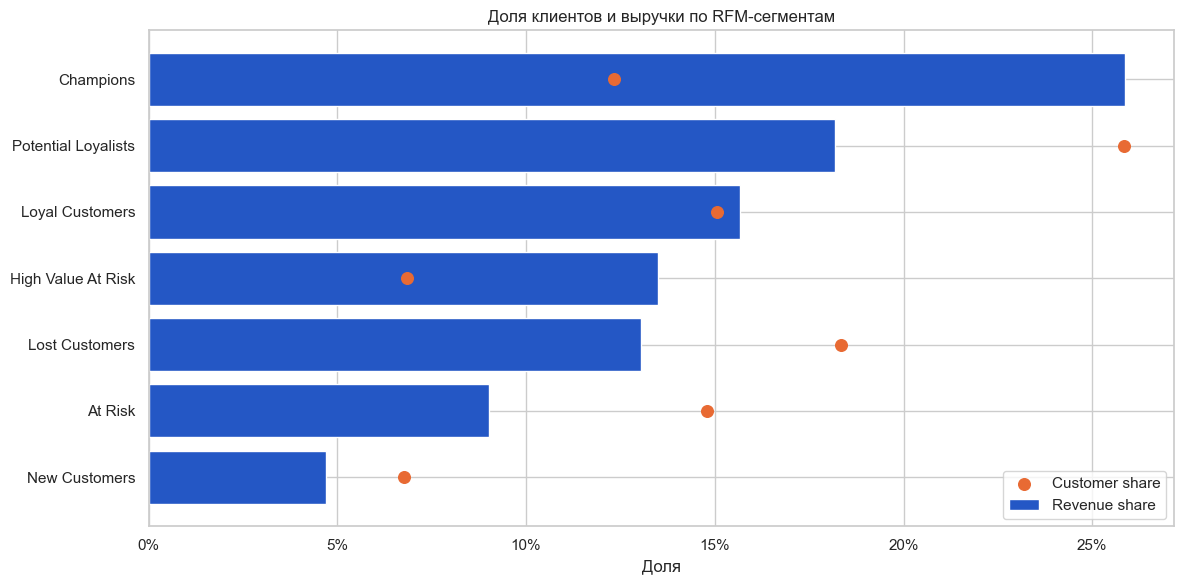

In [15]:
# 3.6.2 Сводная таблица и график RFM-сегментов
rfm_summary = (
    rfm_users.groupby("segment", as_index=False)
    .agg(
        customers=("user_id", "nunique"),
        revenue=("monetary", "sum"),
        avg_order_count=("frequency", "mean"),
        avg_recency_days=("recency_days", "mean"),
    )
)

rfm_summary["customer_share"] = rfm_summary["customers"] / rfm_summary["customers"].sum()
rfm_summary["revenue_share"] = rfm_summary["revenue"] / rfm_summary["revenue"].sum()
rfm_summary = rfm_summary.sort_values("revenue", ascending=False)
rfm_summary.to_csv(TABLES_DIR / "08_rfm_segments.csv", index=False)

display(rfm_summary.style.format({
    "customers": "{:,.0f}",
    "revenue": "${:,.0f}",
    "avg_order_count": "{:.2f}",
    "avg_recency_days": "{:.0f}",
    "customer_share": "{:.1%}",
    "revenue_share": "{:.1%}",
}))

plot_data = rfm_summary.sort_values("revenue_share")
fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(plot_data["segment"], plot_data["revenue_share"], color=COLORS["primary"], label="Revenue share")
ax.scatter(plot_data["customer_share"], plot_data["segment"], color=COLORS["accent"], s=70, label="Customer share")
ax.xaxis.set_major_formatter(lambda value, position: f"{value:.0%}")
ax.set_title("Доля клиентов и выручки по RFM-сегментам")
ax.set_xlabel("Доля")
ax.set_ylabel("")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "05_rfm_segments.png", bbox_inches="tight")
plt.show()


### 3.5 Category Economics and Inventory

Для категорий сравниваются Net Revenue, Gross Margin и Item Return Rate. Для складов — стоимость непроданных позиций старше 180 дней и операционные сроки.

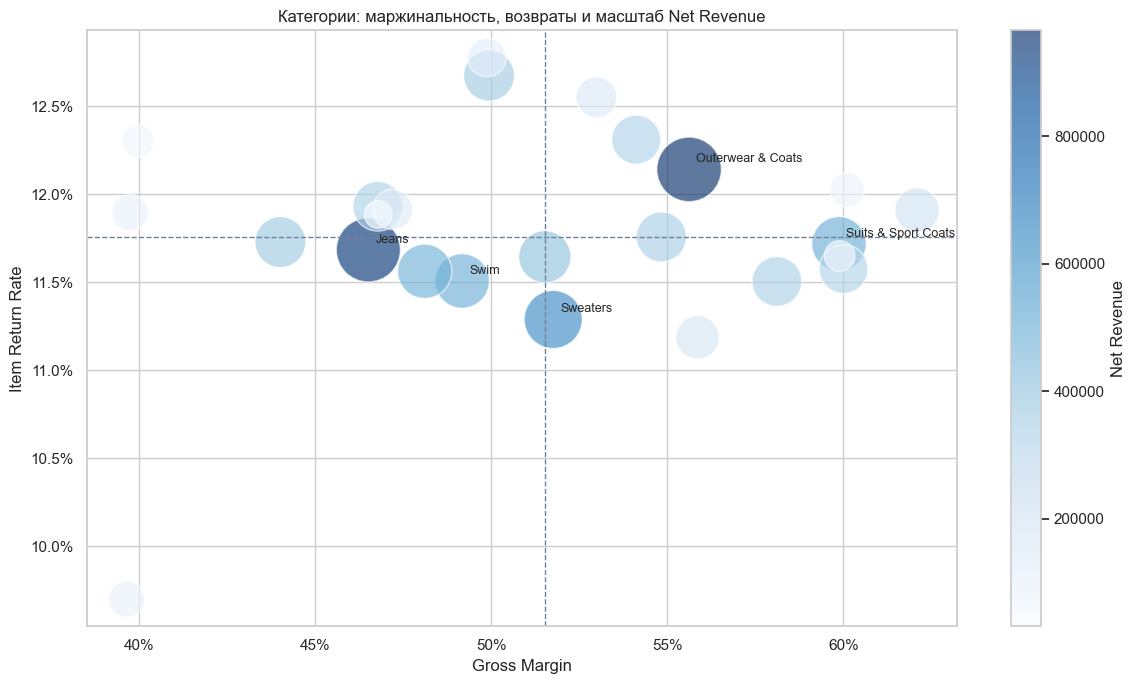

In [16]:
# 3.7 Category economics
item_enriched["net_item_revenue"] = item_enriched["sale_price"].where(~item_enriched["status"].isin(["Cancelled", "Returned"]), 0.0)
item_enriched["net_item_profit"] = item_enriched["item_profit"].where(~item_enriched["status"].isin(["Cancelled", "Returned"]), 0.0)
item_enriched["non_cancelled_item"] = item_enriched["status"].ne("Cancelled").astype("int8")

category = (
    item_enriched.groupby("category", as_index=False, observed=True)
    .agg(
        sold_items=("id", "size"),
        net_revenue=("net_item_revenue", "sum"),
        gross_profit=("net_item_profit", "sum"),
        returned_items=("returned_item", "sum"),
        non_cancelled_items=("non_cancelled_item", "sum"),
    )
)
category["gross_margin"] = category["gross_profit"] / category["net_revenue"]
category["item_return_rate"] = category["returned_items"] / category["non_cancelled_items"]
category = category.query("sold_items >= 500").sort_values("net_revenue", ascending=False)
category.to_csv(TABLES_DIR / "09_category_economics.csv", index=False)

fig, ax = plt.subplots(figsize=(12, 7))
scatter = ax.scatter(category["gross_margin"], category["item_return_rate"],
                     s=np.sqrt(category["net_revenue"]) * 2.2, alpha=0.65,
                     c=category["net_revenue"], cmap="Blues", edgecolor="white")
for _, row in category.nlargest(5, "net_revenue").iterrows():
    ax.annotate(row["category"], (row["gross_margin"], row["item_return_rate"]), xytext=(5, 5), textcoords="offset points", fontsize=9)
ax.axvline(category["gross_margin"].median(), color=COLORS["muted"], linestyle="--", linewidth=1)
ax.axhline(category["item_return_rate"].median(), color=COLORS["muted"], linestyle="--", linewidth=1)
ax.xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.1%}")
ax.set_title("Категории: маржинальность, возвраты и масштаб Net Revenue")
ax.set_xlabel("Gross Margin")
ax.set_ylabel("Item Return Rate")
fig.colorbar(scatter, ax=ax, label="Net Revenue")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "06_category_risk_map.png", bbox_inches="tight")
plt.show()

,distribution_center_id,unsold_units,unsold_cost,aged_units_180d,aged_cost_180d,orders,avg_days_to_ship,avg_days_to_deliver,returned_orders,non_cancelled_orders,return_rate,distribution_center
2,3,"38,255","$1,256,879","30,659","$1,006,420",21446,1.0,3.5,2216,18252,12.1%,Houston TX
0,1,"41,047","$1,136,970","32,972","$912,595",22841,1.0,3.5,2282,19490,11.7%,Memphis TN
1,2,"40,354","$1,052,949","32,245","$842,486",22519,1.0,3.5,2214,19173,11.5%,Chicago IL
7,8,"30,855","$998,299","24,553","$792,755",17317,1.0,3.5,1717,14752,11.6%,Mobile AL
6,7,"28,884","$907,424","23,120","$727,801",16234,1.0,3.5,1623,13768,11.8%,Philadelphia PA
3,4,"29,481","$780,447","23,732","$629,781",16672,1.0,3.5,1674,14199,11.8%,Los Angeles CA
5,6,"27,608","$768,339","22,127","$616,766",15671,1.0,3.5,1578,13261,11.9%,Port Authority of New York/New Jersey NY/NJ
9,10,"20,025","$675,969","16,037","$543,647",11425,1.0,3.5,1183,9758,12.1%,Savannah GA
4,5,"21,831","$644,326","17,508","$514,700",12462,1.0,3.5,1211,10581,11.4%,New Orleans LA
8,9,"28,609","$565,353","22,955","$454,854",16103,1.0,3.5,1632,13596,12.0%,Charleston SC


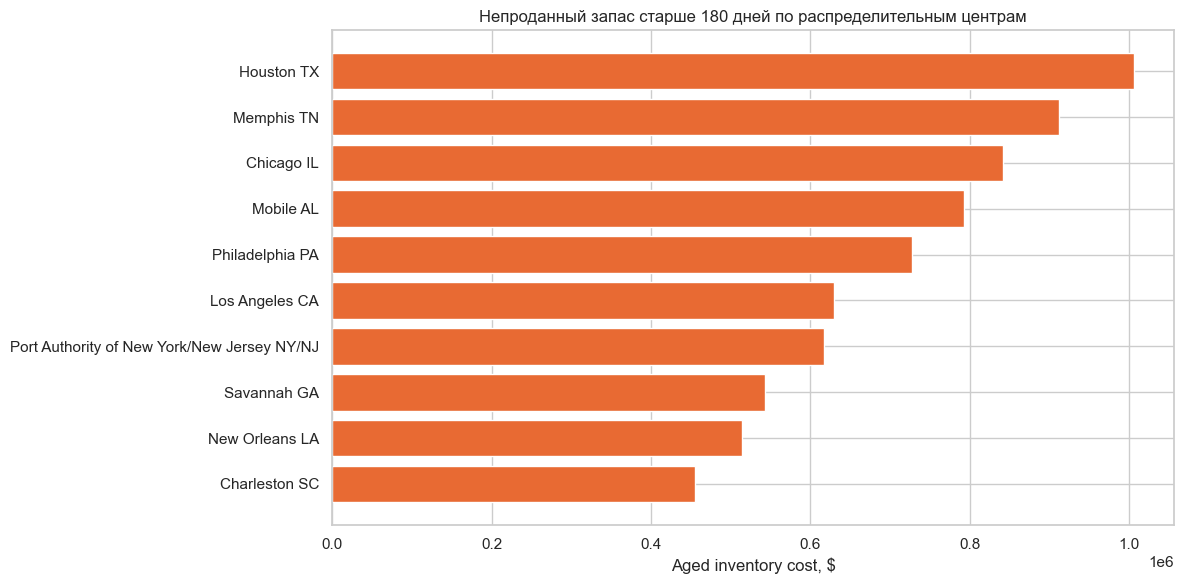

In [17]:
# 3.8 Aged inventory and distribution-center operations
snapshot_at = max(inventory_items["created_at"].max(), inventory_items["sold_at"].max())
inventory_items["is_unsold"] = inventory_items["sold_at"].isna()
inventory_items["age_days"] = (snapshot_at - inventory_items["created_at"]).dt.days
inventory_items["is_aged_180d"] = inventory_items["is_unsold"] & inventory_items["age_days"].gt(180)
inventory_items["unsold_cost"] = inventory_items["cost"].where(inventory_items["is_unsold"], 0.0)
inventory_items["aged_cost_180d"] = inventory_items["cost"].where(inventory_items["is_aged_180d"], 0.0)

inventory_summary = (
    inventory_items.groupby("product_distribution_center_id", as_index=False)
    .agg(
        unsold_units=("is_unsold", "sum"),
        unsold_cost=("unsold_cost", "sum"),
        aged_units_180d=("is_aged_180d", "sum"),
        aged_cost_180d=("aged_cost_180d", "sum"),
    )
    .rename(columns={"product_distribution_center_id": "distribution_center_id"})
)

order_dc = (
    order_items[["order_id", "product_id"]]
    .merge(products_dim[["product_id", "distribution_center_id"]], on="product_id", how="left", validate="many_to_one")
    .drop_duplicates(["order_id", "distribution_center_id"])
    .merge(order_mart[["order_id", "status", "days_to_ship", "days_to_deliver"]], on="order_id", how="left", validate="many_to_one")
)
order_dc["returned_order"] = order_dc["status"].eq("Returned").astype("int8")
order_dc["non_cancelled_order"] = order_dc["status"].ne("Cancelled").astype("int8")
operations = (
    order_dc.groupby("distribution_center_id", as_index=False)
    .agg(
        orders=("order_id", "nunique"),
        avg_days_to_ship=("days_to_ship", "mean"),
        avg_days_to_deliver=("days_to_deliver", "mean"),
        returned_orders=("returned_order", "sum"),
        non_cancelled_orders=("non_cancelled_order", "sum"),
    )
)
operations["return_rate"] = operations["returned_orders"] / operations["non_cancelled_orders"]

dc_dim = distribution_centers.rename(columns={"id": "distribution_center_id", "name": "distribution_center"})
inventory_risk = (
    inventory_summary.merge(operations, on="distribution_center_id", how="left", validate="one_to_one")
    .merge(dc_dim[["distribution_center_id", "distribution_center"]], on="distribution_center_id", how="left", validate="one_to_one")
    .sort_values("aged_cost_180d", ascending=False)
)
inventory_risk.to_csv(TABLES_DIR / "10_inventory_operations.csv", index=False)
display(inventory_risk.head(10).style.format({"unsold_units": "{:,.0f}", "unsold_cost": "${:,.0f}", "aged_units_180d": "{:,.0f}", "aged_cost_180d": "${:,.0f}", "avg_days_to_ship": "{:.1f}", "avg_days_to_deliver": "{:.1f}", "return_rate": "{:.1%}"}))

fig, ax = plt.subplots(figsize=(12, 6))
plot_data = inventory_risk.sort_values("aged_cost_180d")
ax.barh(plot_data["distribution_center"], plot_data["aged_cost_180d"], color=COLORS["accent"])
ax.set_title("Непроданный запас старше 180 дней по распределительным центрам")
ax.set_xlabel("Aged inventory cost, $")
ax.set_ylabel("")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "07_aged_inventory.png", bbox_inches="tight")
plt.show()

### 3.6 Statistical Check: Delivery and Returns

Проверяем простую гипотезу: отличается ли доля возвратов у быстрой и медленной доставки. Используем таблицу сопряжённости и `chi-square`. Это показывает базовую статистику уровня junior+; результат интерпретируется как связь, а не как причинность.


,delivery_group,orders,returned_orders,return_rate,not_returned_orders
0,> 5 дней,"5,748","1,644",28.60%,4104
1,≤ 5 дней,"37,850","10,926",28.87%,26924


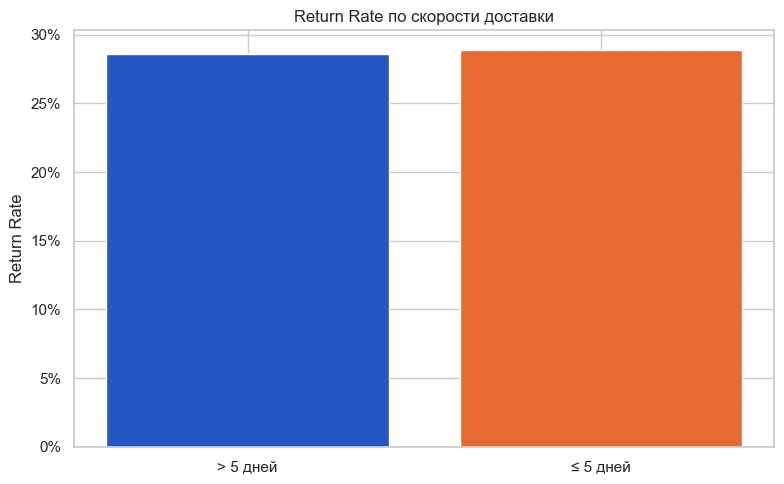

**Chi-square:** χ²=0.16, p-value=0.6905. Вывод: **статистически значимое различие не найдено**. Причинный вывод не делаем.

In [18]:
# 3.9 Скорость доставки и возвраты
delivery_orders = order_mart.loc[
    order_mart["delivered_at"].notna() & order_mart["status"].ne("Cancelled"),
    ["status", "days_to_deliver"],
].copy()

delivery_orders["delivery_group"] = np.where(
    delivery_orders["days_to_deliver"] <= 5,
    "≤ 5 дней",
    "> 5 дней",
)
delivery_orders["returned"] = delivery_orders["status"].eq("Returned").astype(int)

delivery_return = (
    delivery_orders.groupby("delivery_group", as_index=False)
    .agg(
        orders=("returned", "size"),
        returned_orders=("returned", "sum"),
        return_rate=("returned", "mean"),
    )
)
delivery_return["not_returned_orders"] = (
    delivery_return["orders"] - delivery_return["returned_orders"]
)

contingency_table = delivery_return[
    ["returned_orders", "not_returned_orders"]
]
chi2, p_value, _, _ = stats.chi2_contingency(contingency_table)

delivery_return.to_csv(TABLES_DIR / "11_delivery_return_test.csv", index=False)
display(delivery_return.style.format({
    "orders": "{:,.0f}",
    "returned_orders": "{:,.0f}",
    "return_rate": "{:.2%}",
}))

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(
    delivery_return["delivery_group"],
    delivery_return["return_rate"],
    color=[COLORS["primary"], COLORS["accent"]],
)
ax.yaxis.set_major_formatter(lambda value, position: f"{value:.0%}")
ax.set_title("Return Rate по скорости доставки")
ax.set_ylabel("Return Rate")
ax.set_xlabel("")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "08_delivery_return_rate.png", bbox_inches="tight")
plt.show()

if p_value < 0.05:
    test_text = "различие статистически значимо"
else:
    test_text = "статистически значимое различие не найдено"

display(Markdown(
    f"**Chi-square:** χ²={chi2:,.2f}, p-value={p_value:.4f}. "
    f"Вывод: **{test_text}**. Причинный вывод не делаем."
))


## 4. Учебная A/B-симуляция — бесплатная доставка

Проверяем две метрики:

- **Primary metric:** конверсия в покупку.
- **Guardrail:** Contribution per User после субсидии на доставку.

Используем простой и понятный алгоритм:

1. Создаём одинаковые группы control и treatment.
2. Симулируем покупки с разной вероятностью конверсии.
3. Сравниваем конверсии обычным z-test.
4. Проверяем, не ухудшилась ли экономика на пользователя.

Это базовый A/B-анализ уровня junior / junior+. Сложные bootstrap, power analysis и множественные поправки здесь намеренно не используются.


In [19]:
# 4.1 Создаём учебный эксперимент
SAMPLE_SIZE_PER_GROUP = 12_000
BASELINE_CONVERSION = 0.08
TREATMENT_CONVERSION = 0.092
SHIPPING_SUBSIDY = 6.0

total_users = SAMPLE_SIZE_PER_GROUP * 2

# Группы одинакового размера.
groups = np.repeat(["control", "treatment"], SAMPLE_SIZE_PER_GROUP)
rng.shuffle(groups)

# Для каждого пользователя задаём вероятность покупки.
conversion_probability = np.where(
    groups == "control",
    BASELINE_CONVERSION,
    TREATMENT_CONVERSION,
)
converted = rng.binomial(1, conversion_probability)

# Берём реальные чеки и маржу из успешных заказов TheLook.
successful_orders = order_mart.loc[
    order_mart["is_net_order"] & order_mart["order_value"].gt(0),
    ["order_value", "gross_profit_before_status"],
]
sampled_orders = successful_orders.sample(
    n=total_users,
    replace=True,
    random_state=RANDOM_SEED,
).reset_index(drop=True)

experiment = pd.DataFrame({
    "group": groups,
    "converted": converted,
    "order_value": sampled_orders["order_value"],
    "order_profit": sampled_orders["gross_profit_before_status"],
})

experiment["revenue"] = experiment["converted"] * experiment["order_value"]
experiment["gross_profit"] = experiment["converted"] * experiment["order_profit"]
experiment["shipping_cost"] = np.where(
    (experiment["group"] == "treatment") & (experiment["converted"] == 1),
    SHIPPING_SUBSIDY,
    0,
)
experiment["contribution"] = experiment["gross_profit"] - experiment["shipping_cost"]

print("Пользователей в эксперименте:", total_users)
display(experiment.head())


Пользователей в эксперименте: 24000


,group,converted,order_value,order_profit,revenue,gross_profit,shipping_cost,contribution
0,treatment,1,145.000,74.385,145.000,74.385,6.000,68.385
1,control,0,78.750,46.226,0.000,0.000,0.000,0.000
2,control,0,399.940,226.508,0.000,0.000,0.000,0.000
3,treatment,0,11.990,6.475,0.000,0.000,0.000,0.000
4,control,0,94.640,36.324,0.000,0.000,0.000,0.000


In [20]:
# 4.2 Считаем метрики и проводим z-test конверсии
ab_summary = (
    experiment.groupby("group", as_index=False)
    .agg(
        users=("converted", "size"),
        conversions=("converted", "sum"),
        conversion=("converted", "mean"),
        revenue_per_user=("revenue", "mean"),
        contribution_per_user=("contribution", "mean"),
    )
    .set_index("group")
    .reindex(["control", "treatment"])
    .reset_index()
)

conversions = ab_summary["conversions"].to_numpy()
users = ab_summary["users"].to_numpy()
z_stat, conversion_p_value = proportions_ztest(conversions, users)

control_conversion = ab_summary.loc[0, "conversion"]
treatment_conversion = ab_summary.loc[1, "conversion"]
conversion_uplift = treatment_conversion - control_conversion

# Простой 95% доверительный интервал для разницы конверсий.
standard_error = np.sqrt(
    control_conversion * (1 - control_conversion) / users[0]
    + treatment_conversion * (1 - treatment_conversion) / users[1]
)
ci_low = conversion_uplift - 1.96 * standard_error
ci_high = conversion_uplift + 1.96 * standard_error

test_results = pd.DataFrame([{
    "metric": "conversion",
    "uplift": conversion_uplift,
    "ci_low": ci_low,
    "ci_high": ci_high,
    "p_value": conversion_p_value,
    "significant": conversion_p_value < 0.05,
}])

ab_summary.to_csv(TABLES_DIR / "12_ab_summary.csv", index=False)
test_results.to_csv(TABLES_DIR / "13_ab_statistical_tests.csv", index=False)

display(ab_summary.style.format({
    "users": "{:,.0f}",
    "conversions": "{:,.0f}",
    "conversion": "{:.2%}",
    "revenue_per_user": "${:.2f}",
    "contribution_per_user": "${:.2f}",
}))

print(f"Uplift конверсии: {conversion_uplift:.2%}")
print(f"95% CI: от {ci_low:.2%} до {ci_high:.2%}")
print(f"p-value: {conversion_p_value:.4f}")


,group,users,conversions,conversion,revenue_per_user,contribution_per_user
0,control,"12,000",955,7.96%,$6.82,$3.54
1,treatment,"12,000","1,095",9.12%,$7.97,$3.55


Uplift конверсии: 1.17%
95% CI: от 0.46% до 1.87%
p-value: 0.0012


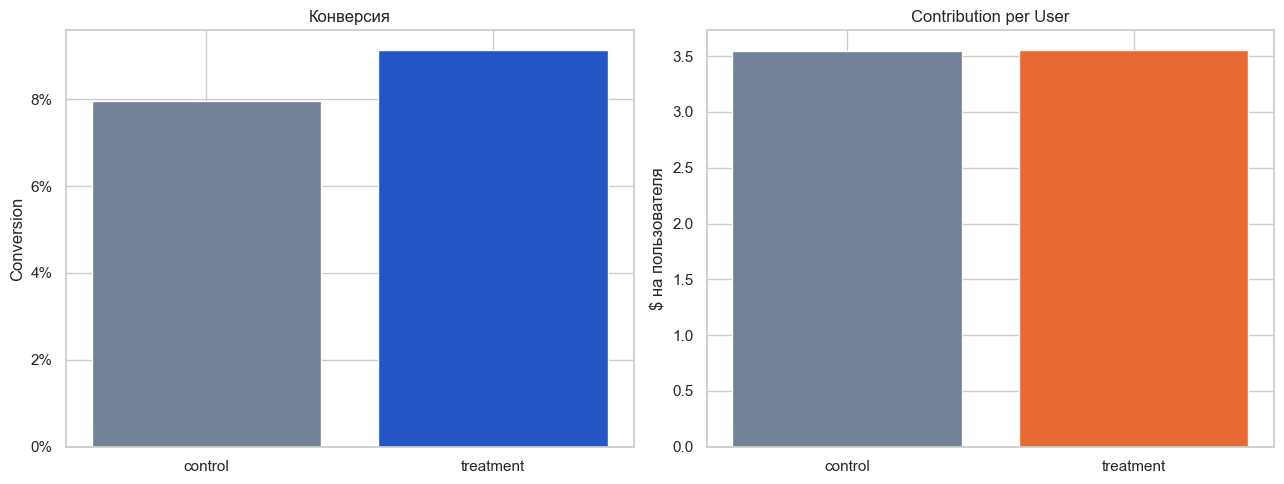

### Решение: PILOT: конверсия выросла, экономика не ухудшилась в симуляции

Conversion: **7.96% → 9.12%**. Contribution per User: **$3.54 → $3.55**.

In [21]:
# 4.3 Визуализируем результат и принимаем решение
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(
    ab_summary["group"],
    ab_summary["conversion"],
    color=[COLORS["muted"], COLORS["primary"]],
)
axes[0].set_title("Конверсия")
axes[0].set_ylabel("Conversion")
axes[0].yaxis.set_major_formatter(lambda value, position: f"{value:.0%}")

axes[1].bar(
    ab_summary["group"],
    ab_summary["contribution_per_user"],
    color=[COLORS["muted"], COLORS["accent"]],
)
axes[1].set_title("Contribution per User")
axes[1].set_ylabel("$ на пользователя")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "09_ab_test_readout.png", bbox_inches="tight")
plt.show()

control_profit = ab_summary.loc[0, "contribution_per_user"]
treatment_profit = ab_summary.loc[1, "contribution_per_user"]

if conversion_p_value < 0.05 and treatment_profit > control_profit:
    decision = "PILOT: конверсия выросла, экономика не ухудшилась в симуляции"
elif conversion_p_value < 0.05 and treatment_profit <= control_profit:
    decision = "ITERATE: конверсия выросла, но экономика ухудшилась"
else:
    decision = "DO NOT LAUNCH: рост конверсии не подтверждён"

display(Markdown(
    f"### Решение: {decision}\n\n"
    f"Conversion: **{control_conversion:.2%} → {treatment_conversion:.2%}**. "
    f"Contribution per User: **${control_profit:.2f} → ${treatment_profit:.2f}**."
))


## 5. Takeaways

Рекомендации ниже формируются из выполненных Pandas-расчётов. SQL-версии тех же метрик находятся в `../sql/`.

In [22]:
# 5.1 Итоговые выводы на основе расчётов
top_rfm = rfm_summary.iloc[0]
high_return_category = category.sort_values(
    ["item_return_rate", "net_revenue"],
    ascending=False,
).iloc[0]
aged_dc = inventory_risk.iloc[0]

m1 = weighted_retention.get("M1", np.nan)
m3 = weighted_retention.get("M3", np.nan)
purchase_conversion = funnel.loc[
    funnel["stage"] == "Покупка",
    "conversion_from_all",
].iloc[0]

executive_summary = f"""
### Подтверждённые результаты Pandas-анализа

1. Net Revenue Proxy = **${kpi.net_revenue.iloc[0]:,.0f}**, Gross Profit Proxy = **${kpi.gross_profit.iloc[0]:,.0f}**, margin = **{kpi.gross_margin.iloc[0]:.1%}**.
2. Return Rate = **{kpi.return_rate.iloc[0]:.1%}**, Cancellation Rate = **{kpi.cancellation_rate.iloc[0]:.1%}**.
3. Repeat Purchase Rate = **{kpi.repeat_purchase_rate.iloc[0]:.1%}**; M1 retention = **{m1:.1%}**, M3 = **{m3:.1%}**.
4. Session purchase conversion = **{purchase_conversion:.1%}**.
5. Сегмент **{top_rfm.segment}** создаёт **{top_rfm.revenue_share:.1%}** Net Revenue при доле клиентов **{top_rfm.customer_share:.1%}**.
6. Категория **{high_return_category.category}** имеет Item Return Rate **{high_return_category.item_return_rate:.1%}**.
7. Наибольший aged inventory risk — **{aged_dc.distribution_center}: ${aged_dc.aged_cost_180d:,.0f}**.
8. Решение по A/B-симуляции — **{decision}**.

### Рекомендации

| Приоритет | Действие | KPI |
|---|---|---|
| P0 | Мониторить Net Revenue, Margin, Return и Cancellation вместо одного GMV | Net Revenue, Margin |
| P1 | Запустить CRM-сценарий второй покупки в первые 30 дней | M1 retention |
| P1 | Диагностировать размерные сетки и карточки рискованных категорий | Item Return Rate |
| P1 | Реактивировать At Risk / High Value At Risk без скидки всем клиентам | Incremental profit |
| P2 | Снизить aged stock в {aged_dc.distribution_center} | Aged inventory cost |
| P2 | Бесплатную доставку запускать только при положительном profit guardrail | Contribution/User |

### Ограничения

- Датасет и A/B-тест синтетические.
- Нет маркетинговых затрат, налогов, платежей, поддержки и NPS.
- Последний месяц неполный; правый край когорт цензурирован.
- Наблюдательные связи не являются причинными эффектами.
"""

display(Markdown(executive_summary))
(OUTPUT_DIR / "executive_summary.md").write_text(executive_summary, encoding="utf-8")



### Подтверждённые результаты Pandas-анализа

1. Net Revenue Proxy = **$8,067,639**, Gross Profit Proxy = **$4,185,726**, margin = **51.9%**.
2. Return Rate = **11.8%**, Cancellation Rate = **15.0%**.
3. Repeat Purchase Rate = **30.4%**; M1 retention = **5.1%**, M3 = **3.9%**.
4. Session purchase conversion = **26.6%**.
5. Сегмент **Champions** создаёт **25.9%** Net Revenue при доле клиентов **12.3%**.
6. Категория **Plus** имеет Item Return Rate **12.8%**.
7. Наибольший aged inventory risk — **Houston TX: $1,006,420**.
8. Решение по A/B-симуляции — **PILOT: конверсия выросла, экономика не ухудшилась в симуляции**.

### Рекомендации

| Приоритет | Действие | KPI |
|---|---|---|
| P0 | Мониторить Net Revenue, Margin, Return и Cancellation вместо одного GMV | Net Revenue, Margin |
| P1 | Запустить CRM-сценарий второй покупки в первые 30 дней | M1 retention |
| P1 | Диагностировать размерные сетки и карточки рискованных категорий | Item Return Rate |
| P1 | Реактивировать At Risk / High Value At Risk без скидки всем клиентам | Incremental profit |
| P2 | Снизить aged stock в Houston TX | Aged inventory cost |
| P2 | Бесплатную доставку запускать только при положительном profit guardrail | Contribution/User |

### Ограничения

- Датасет и A/B-тест синтетические.
- Нет маркетинговых затрат, налогов, платежей, поддержки и NPS.
- Последний месяц неполный; правый край когорт цензурирован.
- Наблюдательные связи не являются причинными эффектами.


1462

In [23]:
# 5.2 Финальные проверки воспроизводимости
sql_query_files = len(list((PROJECT_ROOT / "sql").glob("*.sql")))

manifest = {
    "analysis_engine": "Pandas",
    "code_level": "Junior / Junior+",
    "dataset": "bigquery-public-data.thelook_ecommerce",
    "snapshot": "Kaggle CSV mirror v1, 2022-07-28",
    "random_seed": RANDOM_SEED,
    "row_counts": {name: int(len(table)) for name, table in frames.items()},
    "order_mart_rows": int(len(order_mart)),
    "order_mart_unique_orders": int(order_mart["order_id"].nunique()),
    "data_quality_issue_count": quality_issue_count,
    "tables_exported": len(list(TABLES_DIR.glob("*.csv"))),
    "figures_exported": len(list(FIGURES_DIR.glob("*.png"))),
    "sql_query_files": sql_query_files,
}

(OUTPUT_DIR / "run_manifest.json").write_text(
    json.dumps(manifest, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

assert manifest["order_mart_rows"] == manifest["order_mart_unique_orders"]
assert manifest["data_quality_issue_count"] == 0
assert funnel["sessions"].is_monotonic_decreasing
assert np.isclose(rfm_summary["customer_share"].sum(), 1.0)
assert np.isclose(rfm_summary["revenue_share"].sum(), 1.0)
assert retention_long["retention"].dropna().between(0, 1).all()
assert manifest["tables_exported"] >= 13
assert manifest["figures_exported"] >= 9

if RUNNING_IN_REPOSITORY:
    assert sql_query_files >= 10
    sql_status = f"✅ **SQL вынесен отдельно:** {sql_query_files} BigQuery-файлов."
else:
    sql_status = "ℹ️ **Автономный режим:** SQL-папка не проверялась."

display(Markdown(
    f"✅ **Pandas notebook выполнен:** {manifest['tables_exported']} таблиц и {manifest['figures_exported']} графиков.  \n"
    f"✅ **Гранулярность:** {manifest['order_mart_rows']:,} строк = {manifest['order_mart_unique_orders']:,} уникальных заказов.  \n"
    f"✅ **Уровень кода:** Junior / Junior+.  \n"
    f"{sql_status}  \n"
    f"✅ **Data Quality Gate:** пройден."
))


✅ **Pandas notebook выполнен:** 13 таблиц и 9 графиков.  
✅ **Гранулярность:** 124,923 строк = 124,923 уникальных заказов.  
✅ **Уровень кода:** Junior / Junior+.  
✅ **SQL вынесен отдельно:** 10 BigQuery-файлов.  
✅ **Data Quality Gate:** пройден.